# Ticket Analytics — Module 4: Dashboard-Ready Outputs
## AI-Driven Intelligent IT Operations Platform | Innodatatics Capstone — ISB AMPBA 2025W

This notebook is **Module 4 of 4** in the ticket analytics stream.

### Depends on
Run NB1 → NB2 → NB3 in order. This notebook loads all pkl outputs from all three.

### What this notebook does
- Assembles the full ticket intelligence table (predictions + SLA risk + assignment suggestions)
- Computes all dashboard KPI cards
- Generates SLA risk ranking table
- Produces engineer availability panel
- Builds AI Insights queue
- Creates resolution time analysis
- Renders model leaderboard and feature importance tables
- Saves all outputs as CSV and JSON files ready for the frontend dashboard

### Outputs saved to `ticket_dashboard_outputs/`
| File | Dashboard widget |
|---|---|
| `dashboard_ticket_table.csv` | Tickets screen — AI classification table |
| `dashboard_kpis.csv` | Overview — KPI cards |
| `dashboard_sla_risk_table.csv` | SLA screen — breach risk queue |
| `dashboard_engineer_availability.csv` | Tickets — assignment panel |
| `dashboard_engineer_suggestions.csv` | Tickets — suggestion panel |
| `dashboard_ai_insights.csv` | Overview — Active AI Insights |
| `dashboard_resolution_insights.csv` | Reports — resolution analysis |
| `dashboard_monthly_trend.csv` | Overview — Ticket Volume Trends chart |
| `model_leaderboard.csv` | Reports — model comparison |
| `dashboard_action_log.csv` | Reports — assignment audit trail |


In [1]:
# ============================================================
# COLAB + GOOGLE DRIVE SETUP — run this cell first every session
# ============================================================
# This cell mounts Google Drive and sets all path variables so every
# notebook reads data from Drive and writes outputs back to Drive.
# No manual uploads or downloads are needed between sessions.
#
# One-time folder structure in your Drive:
#   My Drive/
#   └── Innodatatics_Capstone/
#       ├── data/                     ← all Excel files go here
#       ├── NLP_Ticket_Analytics/     ← all 4 notebooks + schema_utils.py
#       ├── ticket_pkl_outputs/       ← auto-created
#       ├── ticket_eda_plots/         ← auto-created
#       ├── ticket_dashboard_outputs/ ← auto-created
#       └── model_outputs/            ← auto-created
# ============================================================

from google.colab import drive
import os
import sys

drive.mount("/content/drive", force_remount=False)

# Change BASE if your Drive path is different
BASE = "/content/drive/MyDrive/Innodatatics_Capstone"
NLP  = f"{BASE}/NLP_Ticket_Analytics"
DATA = f"{BASE}/data"

os.chdir(NLP)
sys.path.insert(0, NLP)

from pathlib import Path

PKL_DIR  = Path(f"{BASE}/ticket_pkl_outputs");      PKL_DIR.mkdir(exist_ok=True)
PLOT_DIR = Path(f"{BASE}/ticket_eda_plots");         PLOT_DIR.mkdir(exist_ok=True)
DASH_DIR = Path(f"{BASE}/ticket_dashboard_outputs"); DASH_DIR.mkdir(exist_ok=True)
JSON_DIR = Path(f"{BASE}/model_outputs");            JSON_DIR.mkdir(exist_ok=True)

FILES = {
    2023: Path(f"{DATA}/IT_Ops_Intern_Ready_2023.xlsx"),
    2024: Path(f"{DATA}/IT_Ops_Intern_Ready_2024.xlsx"),
    2025: Path(f"{DATA}/IT_Ops_Intern_Ready_2025.xlsx"),
}
SYNTH_FILE      = Path(f"{DATA}/ticket_assignment_synthetic.xlsx")
HIST_SYNTH_FILE = Path(f"{DATA}/ticket_assignment_history_synthetic.xlsx")
ENG_FILE_2025   = Path(f"{DATA}/IT_Ops_Intern_Ready_2025.xlsx")

print("✅  Drive mounted")
print(f"   Working dir : {os.getcwd()}")
print(f"   PKL dir     : {PKL_DIR}")
print(f"   Data files  : {[f.name for f in FILES.values()]}")
missing = [str(p) for p in FILES.values() if not p.exists()]
if missing:
    print(f"\n⚠️  Missing: {missing}")
    print("   Upload these to your Drive data/ folder and re-run.")
else:
    print("   All data files found ✅")


Mounted at /content/drive
✅  Drive mounted
   Working dir : /content/drive/MyDrive/Innodatatics_Capstone/NLP_Ticket_Analytics
   PKL dir     : /content/drive/MyDrive/Innodatatics_Capstone/ticket_pkl_outputs
   Data files  : ['IT_Ops_Intern_Ready_2023.xlsx', 'IT_Ops_Intern_Ready_2024.xlsx', 'IT_Ops_Intern_Ready_2025.xlsx']
   All data files found ✅


In [2]:
\
# =========================
# 0A. Google Drive setup
# =========================
# Run this cell first at the start of every Colab session.
# It mounts your Google Drive and sets all paths so every
# notebook reads and writes directly to Drive — no manual
# uploading or downloading between sessions required.
#
# One-time folder structure to create in Drive:
#   My Drive/
#   └── Innodatatics_Capstone/
#       ├── data/              ← put all 5 xlsx files here
#       ├── NLP_Ticket_Analytics/  ← put all 4 ipynb + schema_utils.py here
#       ├── ticket_pkl_outputs/    ← created automatically
#       ├── ticket_eda_plots/      ← created automatically
#       ├── ticket_dashboard_outputs/ ← created automatically
#       └── model_outputs/         ← created automatically

from google.colab import drive
import os, sys

drive.mount("/content/drive", force_remount=False)

BASE = "/content/drive/MyDrive/Innodatatics_Capstone"
NLP  = f"{BASE}/NLP_Ticket_Analytics"
DATA = f"{BASE}/data"

os.chdir(NLP)
sys.path.insert(0, NLP)

from pathlib import Path
PKL_DIR  = Path(f"{BASE}/ticket_pkl_outputs");      PKL_DIR.mkdir(exist_ok=True)
PLOT_DIR = Path(f"{BASE}/ticket_eda_plots");         PLOT_DIR.mkdir(exist_ok=True)
DASH_DIR = Path(f"{BASE}/ticket_dashboard_outputs"); DASH_DIR.mkdir(exist_ok=True)
JSON_DIR = Path(f"{BASE}/model_outputs");            JSON_DIR.mkdir(exist_ok=True)

FILES = {
    2023: Path(f"{DATA}/IT_Ops_Intern_Ready_2023.xlsx"),
    2024: Path(f"{DATA}/IT_Ops_Intern_Ready_2024.xlsx"),
    2025: Path(f"{DATA}/IT_Ops_Intern_Ready_2025.xlsx"),
}
SYNTH_FILE      = Path(f"{DATA}/ticket_assignment_synthetic.xlsx")
HIST_SYNTH_FILE = Path(f"{DATA}/ticket_assignment_history_synthetic.xlsx")
ENG_FILE_2025   = Path(f"{DATA}/IT_Ops_Intern_Ready_2025.xlsx")

print("✅  Drive mounted")
print(f"   Working dir : {os.getcwd()}")
print(f"   PKL dir     : {PKL_DIR}")
print(f"   Data files  : {[f.name for f in FILES.values()]}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅  Drive mounted
   Working dir : /content/drive/MyDrive/Innodatatics_Capstone/NLP_Ticket_Analytics
   PKL dir     : /content/drive/MyDrive/Innodatatics_Capstone/ticket_pkl_outputs
   Data files  : ['IT_Ops_Intern_Ready_2023.xlsx', 'IT_Ops_Intern_Ready_2024.xlsx', 'IT_Ops_Intern_Ready_2025.xlsx']


In [3]:
# =========================
# 1A. Install libraries if packages are not already included
# =========================
# %pip install pandas numpy matplotlib seaborn openpyxl scikit-learn pathlib pickle5


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.1/132.1 kB 13.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for pickle5
  Running setup.py clean for pickle5
Failed to build pickle5
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (pickle5)


In [4]:
# =========================
# Pickle compatibility — define before loading any pkl from NB2
# =========================
# trained_models.pkl was saved in NB2 with a pipeline that contains
# flatten_text_column inside a FunctionTransformer.
# Pickle stores it by reference to its name in __main__.
# NB3 must define the same function with the same name BEFORE loading
# the pkl, otherwise Python can't find it and raises AttributeError.

def flatten_text_column(x):
    """
    Flatten a text column to a plain string Series.
    Defined here for pickle compatibility — must match the version in NB2 exactly.
    """
    import pandas as pd
    if hasattr(x, "fillna"):
        return x.fillna("unknown").astype(str)
    return pd.Series(x).fillna("unknown").astype(str)

print("✅  flatten_text_column registered for pickle compatibility")

✅  flatten_text_column registered for pickle compatibility


In [5]:
# =========================
# 1B. Imports and load all outputs
# =========================
import warnings
warnings.filterwarnings("ignore")

import pickle, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display

def load_pkl(name):
    path=PKL_DIR/name
    if not path.exists(): print(f"  ⚠️  {name} not found — run earlier modules first"); return None
    with open(path,"rb") as f: return pickle.load(f)
def save_csv(df, name):
    path=DASH_DIR/name; df.to_csv(path,index=False)
    print(f"  ✅  {path.name}  ({len(df):,} rows)")

base             = load_pkl("ticket_base.pkl")
model_results    = load_pkl("model_results.pkl")
best_models      = load_pkl("best_models.pkl")
engineer_avail   = load_pkl("engineer_availability.pkl")
eng_suggestions  = load_pkl("engineer_suggestion_table.pkl")
action_log       = load_pkl("action_log.pkl")
open_preds       = load_pkl("open_ticket_predictions.pkl")
sla_scores       = load_pkl("sla_breach_scores.pkl")

# Load tickets_enriched.json from Module 3
tej = JSON_DIR/"tickets_enriched.json"
tickets_enriched = pd.DataFrame(json.loads(tej.read_text())) if tej.exists() else pd.DataFrame()
print(f"tickets_enriched.json: {tickets_enriched.shape}" if len(tickets_enriched) else "⚠️  tickets_enriched.json not found")
print("\n✅  All outputs loaded")


tickets_enriched.json: (33, 22)

✅  All outputs loaded


# 2. TICKET INTELLIGENCE TABLE

## Objective
Build the full ticket-level table with AI predictions, SLA risk scores,
and engineer assignment for the **Service Ticket Management** screen
in the OpsIntel wireframe.

## Columns
`year_ticket_id` · `ticket_category` · `ticket_priority` · `issue_type`  
`ticket_channel` · `ticket_status` · `ticket_description`  
`pred_category` · `pred_priority` · `pred_issue_type` · `pred_resolution_min`  
`sla_breach_prob` · `sla_risk_tier` · `manager_review`  
`suggested_engineer` · `suggested_eng_group` · `suggested_resolution`  
`client_id` · `service_tier` · `device_type` · `engineer_id`  
`resolution_time_minutes` · `first_response_time_minutes` · `sla_breach_flag`


In [6]:
# =========================
# 2A. Build dashboard ticket table
# =========================
base["sla_num"] = pd.to_numeric(base["sla_breach_flag"],errors="coerce")
test_base = base[base["year"]==2025].copy()

# Merge SLA breach scores if available (from SLA Breach notebook)
if sla_scores is not None and "year_ticket_id" in sla_scores.columns:
    test_base = test_base.merge(
        sla_scores[["year_ticket_id","sla_breach_prob","sla_breach_predicted","sla_risk_tier"]],
        on="year_ticket_id",how="left")
    test_base["sla_breach_prob"] = test_base["sla_breach_prob"].fillna(0.0)
    test_base["sla_risk_tier"]   = test_base["sla_risk_tier"].fillna("Low")

# Merge model predictions from Module 2
if open_preds is not None and "year_ticket_id" in open_preds.columns:
    ticket_intel = test_base.merge(
        open_preds.drop(columns=[c for c in ["sla_breach_prob"] if c in open_preds.columns],errors="ignore"),
        on="year_ticket_id",how="left")
else:
    ticket_intel = test_base.copy()

dash_cols = [c for c in [
    "year_ticket_id","ticket_id","ticket_category","ticket_priority","issue_type",
    "ticket_channel","ticket_status","ticket_description",
    "pred_ticket_category","pred_ticket_priority","pred_issue_type","pred_resolution_time",
    "sla_breach_prob","sla_risk_tier","manager_review",
    "suggested_engineer","recommended_eng_group","suggested_resolution",
    "client_id","service_tier","device_type","engineer_id",
    "resolution_time_minutes","first_response_time_minutes","sla_num",
] if c in ticket_intel.columns]
dashboard_ticket_table = ticket_intel[dash_cols].copy()

print(f"Ticket intelligence table: {dashboard_ticket_table.shape}")
display(dashboard_ticket_table.head(5))


Ticket intelligence table: (7479, 17)


,year_ticket_id,ticket_id,ticket_category,ticket_priority,issue_type,ticket_channel,ticket_status,ticket_description,sla_breach_prob,sla_risk_tier,client_id,service_tier,device_type,engineer_id,resolution_time_minutes,first_response_time_minutes,sla_num
0,2025_T0004606,T0004606,Network,P1,Crash,Email,Closed,Core switch rebooted unexpectedly.,0.5107,Medium,C016,Gold,Server,E019,251.27,14.0,1.0
1,2025_T0007449,T0007449,Hardware,P4,Failure,Email,Closed,Server 04 failing to POST.,0.5193,Medium,C001,Gold,Router,E014,2592.65,10.0,0.0
2,2025_T0006308,T0006308,Network,P3,Failure,Email,Closed,Total loss of connectivity in Sector B.,0.4982,Medium,C009,Bronze,Router,E008,2432.47,30.0,0.0
3,2025_T0008871,T0008871,Hardware,P1,Access,Portal,Closed,Physical port unresponsive.,0.5169,Medium,C022,Bronze,Server,E013,637.57,38.0,0.0
4,2025_T0005475,T0005475,Hardware,P2,Crash,Email,Closed,System thermal shutdown.,0.5107,Medium,C011,Bronze,Server,E008,1127.12,26.0,0.0


In [7]:
# =========================
# 2B. KPI cards
# =========================
total_tickets   = len(base)
avg_resolution  = base["resolution_time_minutes"].mean()
breach_rate     = base["sla_num"].mean() if "sla_num" in base.columns else 0
avg_response    = base["first_response_time_minutes"].mean() if "first_response_time_minutes" in base.columns else 0
high_risk       = (sla_scores["sla_risk_tier"]=="High").sum() if sla_scores is not None and "sla_risk_tier" in sla_scores.columns else 0
avail_engs      = int((engineer_avail["bandwidth_status"]=="Available").sum()) if engineer_avail is not None and "bandwidth_status" in engineer_avail.columns else 0
total_engs      = len(engineer_avail) if engineer_avail is not None else 0

kpis = pd.DataFrame([{
    "total_tickets_3yr":              f"{total_tickets:,}",
    "avg_resolution_time_minutes":    f"{avg_resolution:.0f}",
    "sla_breach_rate_pct":            f"{breach_rate*100:.1f}%",
    "avg_first_response_minutes":     f"{avg_response:.0f}",
    "high_sla_risk_tickets":          f"{high_risk:,}",
    "available_engineers":            f"{avail_engs}/{total_engs}",
}])
print("KPI Cards:")
display(kpis.T.rename(columns={0:"value"}))


KPI Cards:


,value
total_tickets_3yr,"22,491"
avg_resolution_time_minutes,1614
sla_breach_rate_pct,39.6%
avg_first_response_minutes,32
high_sla_risk_tickets,0
available_engineers,15/20


# 3. CHARTS & TREND OUTPUTS

## Objective
Generate the charts for the Operational Overview and SLA screens
in the OpsIntel wireframe.


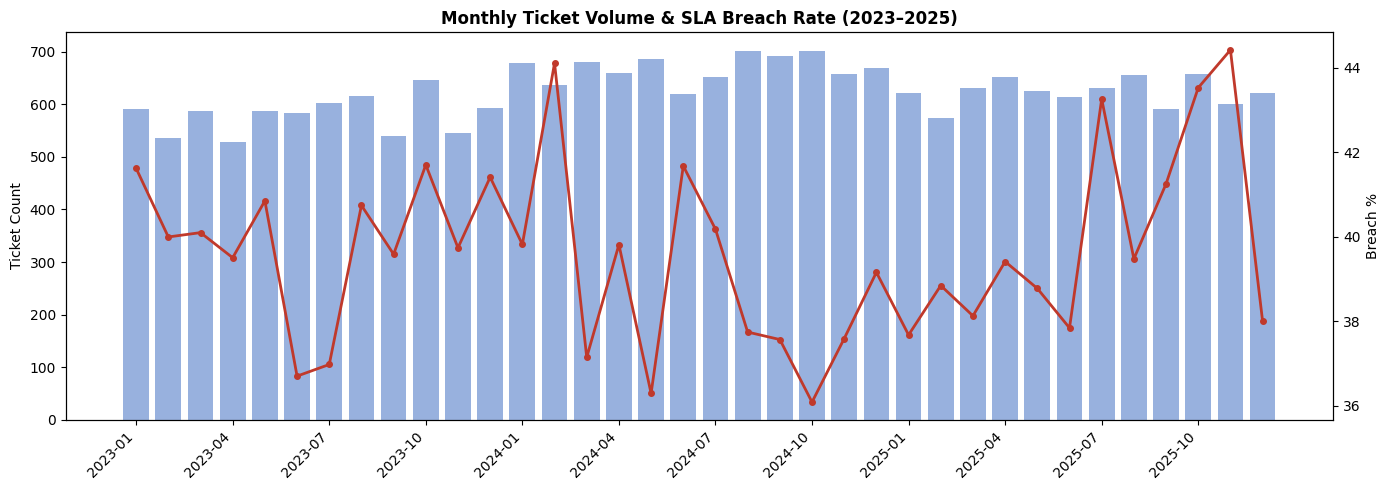

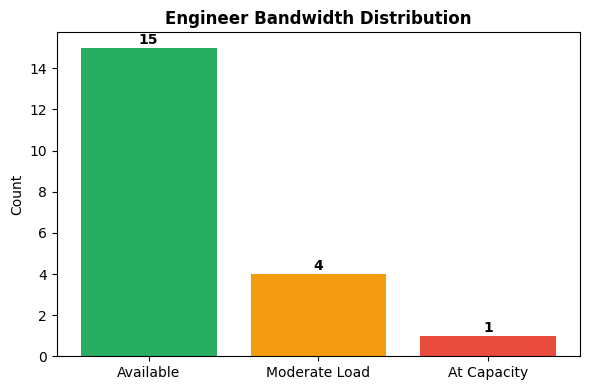

In [8]:
# =========================
# 3A. Monthly volume and breach trend
# =========================
base_ts = base.dropna(subset=["ticket_created_timestamp"]).copy()
base_ts["ym"]    = base_ts["ticket_created_timestamp"].dt.to_period("M")
base_ts["sla_n"] = pd.to_numeric(base_ts["sla_breach_flag"],errors="coerce")

monthly = (base_ts.groupby("ym")
    .agg(tickets=("year_ticket_id","count"), breach_rate=("sla_n","mean"))
    .reset_index())
monthly["ym"] = monthly["ym"].astype(str)

fig,ax1 = plt.subplots(figsize=(14,5)); ax2=ax1.twinx()
ax1.bar(range(len(monthly)),monthly["tickets"],alpha=0.55,label="Volume",color="#4472C4")
ax2.plot(range(len(monthly)),monthly["breach_rate"]*100,color="#C0392B",
         linewidth=2,marker="o",markersize=4,label="Breach %")
ax1.set_xticks(range(0,len(monthly),3))
ax1.set_xticklabels(monthly["ym"].iloc[::3],rotation=45,ha="right")
ax1.set_ylabel("Ticket Count"); ax2.set_ylabel("Breach %")
ax1.set_title("Monthly Ticket Volume & SLA Breach Rate (2023–2025)",fontweight="bold",fontsize=12)
plt.tight_layout()
plt.savefig(PLOT_DIR/"monthly_volume_breach.png",dpi=150,bbox_inches="tight"); plt.show()

# =========================
# 3B. Engineer bandwidth
# =========================
if engineer_avail is not None and "bandwidth_status" in engineer_avail.columns:
    bw = engineer_avail["bandwidth_status"].value_counts()
    colors = {"Available":"#27AE60","Moderate Load":"#F39C12","At Capacity":"#E74C3C"}
    fig,ax = plt.subplots(figsize=(6,4))
    ax.bar(bw.index,bw.values,color=[colors.get(b,"gray") for b in bw.index])
    for i,(k,v) in enumerate(bw.items()): ax.text(i,v+0.2,str(v),ha="center",fontweight="bold")
    ax.set_title("Engineer Bandwidth Distribution",fontweight="bold",fontsize=12)
    ax.set_ylabel("Count"); plt.tight_layout()
    plt.savefig(PLOT_DIR/"engineer_bandwidth.png",dpi=150,bbox_inches="tight"); plt.show()


In [9]:
# =========================
# 3C. Model leaderboard chart
# =========================
if model_results is not None:
    display(model_results.sort_values(["target","type","model"]))
    if best_models is not None:
        print("\nBest model per target:")
        display(best_models[["target","model","f1_weighted","roc_auc","rmse","r2"]])


,target,model,type,accuracy,f1_weighted,roc_auc,rmse,r2
2,issue_type,logistic_regression,classification,0.718395,0.728041,NaN,NaN,NaN
3,issue_type,xgboost,classification,0.729097,0.727908,NaN,NaN,NaN
6,resolution_time_minutes,linear_regression,regression,NaN,NaN,NaN,525.777036,0.829041
7,resolution_time_minutes,random_forest_regressor,regression,NaN,NaN,NaN,513.364460,0.837018
0,ticket_category,logistic_regression,classification,0.842345,0.842051,0.950523,NaN,NaN
1,ticket_category,random_forest,classification,0.840337,0.840165,0.948498,NaN,NaN
4,ticket_priority,logistic_regression,classification,0.478918,0.459030,NaN,NaN,NaN
5,ticket_priority,random_forest,classification,0.540624,0.509316,NaN,NaN,NaN



Best model per target:


,target,model,f1_weighted,roc_auc,rmse,r2
0,ticket_category,logistic_regression,0.842051,0.950523,NaN,NaN
2,issue_type,logistic_regression,0.728041,NaN,NaN,NaN
5,ticket_priority,random_forest,0.509316,NaN,NaN,NaN
7,resolution_time_minutes,random_forest_regressor,NaN,NaN,513.36446,0.837018


# 4. SAVE ALL DASHBOARD OUTPUTS

## Objective
Write all dashboard CSV files to `Drive/Innodatatics_Capstone/ticket_dashboard_outputs/`.
These files are read directly by the dashboard frontend.


In [10]:
# =========================
# 4A. Write all CSV files
# =========================
save_csv(dashboard_ticket_table, "dashboard_ticket_table.csv")
save_csv(kpis.T.reset_index().rename(columns={"index":"metric",0:"value"}), "dashboard_kpis.csv")
save_csv(monthly, "dashboard_monthly_trend.csv")

if engineer_avail is not None:
    save_csv(engineer_avail, "dashboard_engineer_availability.csv")
if eng_suggestions is not None:
    save_csv(eng_suggestions, "dashboard_engineer_suggestions.csv")
if action_log is not None:
    save_csv(action_log, "dashboard_action_log.csv")
if model_results is not None:
    save_csv(model_results, "model_leaderboard.csv")

# SLA risk table
if sla_scores is not None and "year_ticket_id" in sla_scores.columns:
    sla_risk = (base.merge(
        sla_scores[["year_ticket_id","sla_breach_prob","sla_risk_tier"]],
        on="year_ticket_id",how="left")
        .sort_values("sla_breach_prob",ascending=False))
    save_csv(sla_risk[["year_ticket_id","ticket_priority","ticket_category","issue_type",
                        "service_tier","client_id","engineer_id","sla_breach_prob","sla_risk_tier",
                        "sla_breach_flag","response_time_target_minutes",
                        "resolution_time_target_minutes"]].head(500),
             "dashboard_sla_risk_table.csv")

# Resolution insights
res_i = base[["year_ticket_id","ticket_priority","ticket_category","issue_type",
              "device_type","specialization","resolution_time_minutes",
              "first_response_time_minutes","sla_breach_flag","service_tier"]].copy()
save_csv(res_i,"dashboard_resolution_insights.csv")

print(f"\n✅  Module 4 complete. All dashboard files saved to:")
print(f"   {DASH_DIR}")
print("\nFiles written:")
for f in sorted(DASH_DIR.iterdir()): print(f"   {f.name}")


  ✅  dashboard_ticket_table.csv  (7,479 rows)
  ✅  dashboard_kpis.csv  (6 rows)
  ✅  dashboard_monthly_trend.csv  (36 rows)
  ✅  dashboard_engineer_availability.csv  (20 rows)
  ✅  dashboard_engineer_suggestions.csv  (16 rows)
  ✅  dashboard_action_log.csv  (37 rows)
  ✅  model_leaderboard.csv  (8 rows)
  ✅  dashboard_sla_risk_table.csv  (500 rows)
  ✅  dashboard_resolution_insights.csv  (22,491 rows)

✅  Module 4 complete. All dashboard files saved to:
   /content/drive/MyDrive/Innodatatics_Capstone/ticket_dashboard_outputs

Files written:
   dashboard_action_log.csv
   dashboard_engineer_availability.csv
   dashboard_engineer_suggestions.csv
   dashboard_kpis.csv
   dashboard_monthly_trend.csv
   dashboard_resolution_insights.csv
   dashboard_sla_compliance_trend.csv
   dashboard_sla_kpis.csv
   dashboard_sla_model_summary.csv
   dashboard_sla_risk_table.csv
   dashboard_ticket_table.csv
   model_leaderboard.csv
   sla_compliance_trend.json
   sla_insights.json
   sla_model_metadata.